<a href="https://colab.research.google.com/github/geleshChrsitUniversity/randomtest/blob/main/examples/image_classification/image_classification_peft_lora.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Introduction

In this notebook, we will learn how to use [LoRA](https://huggingface.co/papers/2106.09685) from 🤗 PEFT to fine-tune an image classification model by ONLY using **0.77%** of the original trainable parameters of the model.

LoRA adds low-rank "update matrices" to certain blocks in the underlying model (in this case the attention blocks) and ONLY trains those matrices during fine-tuning. During inference, these update matrices are _merged_ with the original model parameters. For more details, check out the [original LoRA paper](https://huggingface.co/papers/2106.09685).

Let's get started by installing the dependencies.

__*Note that this notebook builds on top the [official image classification example notebook](https://github.com/huggingface/notebooks/blob/main/examples/image_classification.ipynb).*__

## Install dependencies

Here we're installing `peft` from source to ensure we have access to all the bleeding edge features of `peft`.

In [41]:
!pip install transformers accelerate evaluate datasets git+https://github.com/huggingface/peft -q
!pip install --upgrade torchao
!pip install evaluate numpy -q

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


## Authentication

We will share our fine-tuned model at the end of training. So, to do that we just authenticate using our 🤗 token. This token is available from [here](https://huggingface.co/settings/tokens). If you don't have a 🤗 account already, we highly encourage you to do so; it's free!

In [8]:
from huggingface_hub import notebook_login

notebook_login()

## Check the library versions

In [9]:
import transformers
import accelerate
import peft

In [10]:
print(f"Transformers version: {transformers.__version__}")
print(f"Accelerate version: {accelerate.__version__}")
print(f"PEFT version: {peft.__version__}")

Transformers version: 5.12.1
Accelerate version: 1.14.0
PEFT version: 0.19.1


## Select a model checkpoint to fine-tune

In [11]:
model_checkpoint = "google/vit-base-patch16-224-in21k"  # pre-trained model from which to fine-tune

## Load a dataset

We're only loading the first 5000 instances from the training set of the [Food-101 dataset](https://huggingface.co/datasets/food101) to keep this example runtime short.

In [12]:
from datasets import load_dataset
dataset = load_dataset("ethz/food101", split="train[:5000]")

#dataset = load_dataset("food101", split="train[:5000]")

README.md:   0%|          | 0.00/16.4k [00:00<?, ?B/s]

data/train-00000-of-00008.parquet:   0%|          | 0.00/490M [00:00<?, ?B/s]

data/train-00001-of-00008.parquet:   0%|          | 0.00/464M [00:00<?, ?B/s]

data/train-00002-of-00008.parquet:   0%|          | 0.00/472M [00:00<?, ?B/s]

data/train-00003-of-00008.parquet:   0%|          | 0.00/464M [00:00<?, ?B/s]

...

data/validation-00000-of-00003.parquet:   0%|          | 0.00/423M [00:00<?, ?B/s]

data/validation-00001-of-00003.parquet:   0%|          | 0.00/413M [00:00<?, ?B/s]

data/validation-00002-of-00003.parquet:   0%|          | 0.00/426M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/75750 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/25250 [00:00<?, ? examples/s]

## Prepare datasets for training and evaluation

1. Prepare `label2id` and `id2label` dictionaries. This will come in handy when performing inference and for metadata information.

In [13]:
labels = dataset.features["label"].names
label2id, id2label = dict(), dict()
for i, label in enumerate(labels):
    label2id[label] = i
    id2label[i] = label

id2label[2]

'baklava'

2. We load the image processor of the model we're fine-tuning.

In [14]:
from transformers import AutoImageProcessor

image_processor = AutoImageProcessor.from_pretrained(model_checkpoint)
image_processor

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

ViTImageProcessor {
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.5,
    0.5,
    0.5
  ],
  "image_processor_type": "ViTImageProcessor",
  "image_std": [
    0.5,
    0.5,
    0.5
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 224,
    "width": 224
  }
}

As one might notice, the `image_processor` has useful information on which size the training and evaluation images should be resized, stats that should be used to normalize the pixel values, etc.

3. Using the image processor we prepare transformation functions for the datasets. These functions will include augmentation and pixel scaling.  

In [15]:
from torchvision.transforms import (
    CenterCrop,
    Compose,
    Normalize,
    RandomHorizontalFlip,
    RandomResizedCrop,
    Resize,
    ToTensor,
)

normalize = Normalize(mean=image_processor.image_mean, std=image_processor.image_std)
train_transforms = Compose(
    [
        RandomResizedCrop(image_processor.size["height"]),
        RandomHorizontalFlip(),
        ToTensor(),
        normalize,
    ]
)

val_transforms = Compose(
    [
        Resize(image_processor.size["height"]),
        CenterCrop(image_processor.size["height"]),
        ToTensor(),
        normalize,
    ]
)


def preprocess_train(example_batch):
    """Apply train_transforms across a batch."""
    example_batch["pixel_values"] = [train_transforms(image.convert("RGB")) for image in example_batch["image"]]
    return example_batch


def preprocess_val(example_batch):
    """Apply val_transforms across a batch."""
    example_batch["pixel_values"] = [val_transforms(image.convert("RGB")) for image in example_batch["image"]]
    return example_batch

4. We split our mini dataset into training and validation.

In [16]:
# split up training into training + validation
splits = dataset.train_test_split(test_size=0.1)
train_ds = splits["train"]
val_ds = splits["test"]

5. We set the transformation functions to the datasets accordingly.

In [17]:
train_ds.set_transform(preprocess_train)
val_ds.set_transform(preprocess_val)

## Load and prepare a model

In this section, we first load the model we want to fine-tune.

In [18]:
def print_trainable_parameters(model):
    """
    Prints the number of trainable parameters in the model.
    """
    trainable_params = 0
    all_param = 0
    for _, param in model.named_parameters():
        all_param += param.numel()
        if param.requires_grad:
            trainable_params += param.numel()
    print(
        f"trainable params: {trainable_params} || all params: {all_param} || trainable%: {100 * trainable_params / all_param:.2f}"
    )

The `get_peft_model()` method that we will use in a moment wraps the original model to be fine-tuned as a `PeftModel`. So, it's important for us to initialize the original model correctly. As such, we initialize it by specifying the `label2id` and `id2label` so that `AutoModelForImageClassification` can initialize a append classification head to the underlying model, adapted for our dataset. We can confirm this from the warning below:

```
Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.weight', 'classifier.bias']
```

In [19]:
from transformers import AutoModelForImageClassification, TrainingArguments, Trainer

model = AutoModelForImageClassification.from_pretrained(
    model_checkpoint,
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes=True,  # provide this in case you're planning to fine-tune an already fine-tuned checkpoint
)
print_trainable_parameters(model)

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/6 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                                                     | Status     | 
--------------------------------------------------------+------------+-
encoder.layer.{0...11}.attention.output.dense.weight    | UNEXPECTED | 
encoder.layer.{0...11}.layernorm_after.weight           | UNEXPECTED | 
encoder.layer.{0...11}.intermediate.dense.weight        | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.value.bias   | UNEXPECTED | 
encoder.layer.{0...11}.layernorm_before.bias            | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.query.bias   | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.key.bias     | UNEXPECTED | 
encoder.layer.{0...11}.output.dense.weight              | UNEXPECTED | 
encoder.layer.{0...11}.intermediate.dense.bias          | UNEXPECTED | 
encoder.layer.{0...11}.attention.output.dense.bias      | UNEXPECTED | 
encoder.layer.{0...11}.layernorm_after.bias

trainable params: 85876325 || all params: 85876325 || trainable%: 100.00


Also, take note of the number of total trainable parameters of `model`: it's 100%! We'll compare this number to that of the LoRA model.

We now use the `PeftModel` to wrap `model` so that the "update" matrices are added to the respective places.

In [20]:
from peft import LoraConfig, get_peft_model

config = LoraConfig(
    r=16,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.1,
    bias="none",
    modules_to_save=["classifier"],
)
lora_model = get_peft_model(model, config)
print_trainable_parameters(lora_model)

trainable params: 667493 || all params: 86543818 || trainable%: 0.77


Let's unpack what's going on here.

In order for LoRA to take effect, we need to specify the target modules to `LoraConfig` so that `get_peft_model()` knows which modules inside our model needs to be amended with LoRA matrices. In this case, we're only interested in targetting the query and value matrices of the attention blocks of the base model. Since the parameters corresponding to these matrices are "named" with `query` and `value` respectively, we specify them accordingly in the `target_modules` argument of `LoraConfig`.

We also specify `modules_to_save`. After we wrap our base model `model` with `get_peft_model()` along with the `config`, we get a new model where only the LoRA parameters are trainable (so-called "update matrices") while the pre-trained parameters are kept frozen. These include the parameters of the randomly initialized classifier parameters too. This is NOT we want when fine-tuning the base model on our custom dataset. To ensure that the classifier parameters are also trained, we specify `modules_to_save`. This also ensures that these modules are serialized alongside the LoRA trainable parameters when using utilities like `save_pretrained()` and `push_to_hub()`.  

Regarding the other parameters:

* `r`: The dimension used by the LoRA update matrices.
* `alpha`: Scaling factor.
* `bias`: Specifying if the `bias` parameters should be trained. `None` denotes none of the `bias` parameters will be trained.

`r` and `alpha` together control the total number of final trainable parameters when using LoRA giving us the flexbility to balance a trade-off between end performance and compute efficiency.


We can also how many parameters we're actually training. Since we're interested in performing **parameter-efficient fine-tuning**, we should expect to notice a less number of trainable parameters from the `lora_model` in comparison to the original `model` which is indeed the case here.

## Training arguments

We will leverage [🤗 Trainer](https://huggingface.co/docs/transformers/main_classes/trainer) for fine-tuning. It accepts several arguments which we wrap using [`TrainingArguments`](https://huggingface.co/docs/transformers/main_classes/trainer#transformers.TrainingArguments).

In [21]:
from transformers import TrainingArguments, Trainer


model_name = model_checkpoint.split("/")[-1]
batch_size = 128

args = TrainingArguments(
    f"{model_name}-finetuned-lora-food101",
    remove_unused_columns=False,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-3,
    per_device_train_batch_size=batch_size,
    gradient_accumulation_steps=4,
    per_device_eval_batch_size=batch_size,
    fp16=True,
    num_train_epochs=5,
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    push_to_hub=True,
    label_names=["labels"],
)

Some things to note here:

* We're using a larger batch size since there is only a handful of parameters to train.
* Larger learning rate than the normal (1e-5 for example).

All of these things are a byproduct of the fact that we're training only a small number of parameters. This can potentially also reduce the need to conduct expensive hyperparameter tuning experiments.

## Prepare evaluation metric

In [22]:
import numpy as np
import evaluate

metric = evaluate.load("accuracy")


# the compute_metrics function takes a Named Tuple as input:
# predictions, which are the logits of the model as Numpy arrays,
# and label_ids, which are the ground-truth labels as Numpy arrays.
def compute_metrics(eval_pred):
    """Computes accuracy on a batch of predictions"""
    predictions = np.argmax(eval_pred.predictions, axis=1)
    return metric.compute(predictions=predictions, references=eval_pred.label_ids)

## Collation function

This is used by `Trainer` to gather a batch of training and evaluation examples and prepare them in a format that is acceptable by the underlying model.

In [23]:
import torch


def collate_fn(examples):
    pixel_values = torch.stack([example["pixel_values"] for example in examples])
    labels = torch.tensor([example["label"] for example in examples])
    return {"pixel_values": pixel_values, "labels": labels}

## Train and evaluate

In [24]:
trainer = Trainer(
    lora_model,
    args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=image_processor,
    compute_metrics=compute_metrics,
    data_collator=collate_fn,
)
train_results = trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,No log,1.785251,0.288000
2,2.421697,1.669170,0.362000
3,1.705466,1.535258,0.460000
4,1.575854,1.426374,0.514000
5,1.444125,1.380913,0.510000


In just a few minutes, we have a fine-tuned model with 96% validation accuracy. Also, note that we used a very small subset of the training dataset which is definitely impacting the results.

In [25]:
trainer.evaluate(val_ds)

Training Loss,Validation Loss,Epoch,Accuracy
1.444125,1.426374,5,0.514000


{'eval_loss': 1.4263741970062256, 'eval_accuracy': 0.514}

## Sharing your model and inference

Once the fine-tuning is done, we can share the LoRA parameters with the community like so:

In [26]:
from huggingface_hub import get_full_repo_name

repo_name = get_full_repo_name(f"{model_name}-finetuned-lora-food101")
lora_model.push_to_hub(repo_name)

README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors: 100%|##########| 2.68MB / 2.68MB            

CommitInfo(commit_url='https://huggingface.co/Gelesh/vit-base-patch16-224-in21k-finetuned-lora-food101/commit/a6e02840245f9cc238178eafb86cda379d90bbd3', commit_message='Upload model', commit_description='', oid='a6e02840245f9cc238178eafb86cda379d90bbd3', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Gelesh/vit-base-patch16-224-in21k-finetuned-lora-food101', endpoint='https://huggingface.co', repo_type='model', repo_id='Gelesh/vit-base-patch16-224-in21k-finetuned-lora-food101'), pr_revision=None, pr_num=None)

When we call `push_to_hub()` on the `lora_model`, only the LoRA parameters along with any modules specified in `modules_to_save` are saved. If we take a look at the [trained LoRA parameters](https://huggingface.co/sayakpaul/vit-base-patch16-224-in21k-finetuned-lora-food101/blob/main/adapter_model.bin), we see that it's only **2.6 MB**! This greatly helps with portability especially when we're using a very large model to fine-tune (such as [BLOOM](https://huggingface.co/bigscience/bloom)).

Next, we see how to load the LoRA updated parameters along with our base model for inference. When we wrap a base model with `PeftModel` that modifications are DONE in place. So to mitigate any concerns that might stem from in place modifications, we newly initialize our base model just like we did earlier and construct our inference model.

In [27]:
from peft import PeftConfig, PeftModel


config = PeftConfig.from_pretrained(repo_name)
model = model = AutoModelForImageClassification.from_pretrained(
    config.base_model_name_or_path,
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes=True,  # provide this in case you're planning to fine-tune an already fine-tuned checkpoint
)
# Load the Lora model
inference_model = PeftModel.from_pretrained(model, repo_name)

adapter_config.json:   0%|          | 0.00/1.16k [00:00<?, ?B/s]

Loading weights:   0%|          | 0/6 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                                                     | Status     | 
--------------------------------------------------------+------------+-
encoder.layer.{0...11}.attention.output.dense.weight    | UNEXPECTED | 
encoder.layer.{0...11}.layernorm_after.weight           | UNEXPECTED | 
encoder.layer.{0...11}.intermediate.dense.weight        | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.value.bias   | UNEXPECTED | 
encoder.layer.{0...11}.layernorm_before.bias            | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.query.bias   | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.key.bias     | UNEXPECTED | 
encoder.layer.{0...11}.output.dense.weight              | UNEXPECTED | 
encoder.layer.{0...11}.intermediate.dense.bias          | UNEXPECTED | 
encoder.layer.{0...11}.attention.output.dense.bias      | UNEXPECTED | 
encoder.layer.{0...11}.layernorm_after.bias

adapter_model.safetensors:   0%|          | 0.00/2.68M [00:00<?, ?B/s]

## Experimenting with LoRA Dropout

Let's see how the model performs without LoRA dropout. We will set `lora_dropout=0.0` in the `LoraConfig` and re-train the model.

In [28]:
from peft import LoraConfig, get_peft_model

# Redefine the LoRA config without dropout
config_no_dropout = LoraConfig(
    r=16,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.0, # Dropout set to 0.0
    bias="none",
    modules_to_save=["classifier"],
)

# Re-initialize the base model (as done previously)
model_no_dropout = AutoModelForImageClassification.from_pretrained(
    model_checkpoint,
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes=True,
)

# Get the PEFT model with no dropout
lora_model_no_dropout = get_peft_model(model_no_dropout, config_no_dropout)
print("LoRA model (no dropout) trainable parameters:")
print_trainable_parameters(lora_model_no_dropout)

Loading weights:   0%|          | 0/6 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                                                     | Status     | 
--------------------------------------------------------+------------+-
encoder.layer.{0...11}.attention.output.dense.weight    | UNEXPECTED | 
encoder.layer.{0...11}.layernorm_after.weight           | UNEXPECTED | 
encoder.layer.{0...11}.intermediate.dense.weight        | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.value.bias   | UNEXPECTED | 
encoder.layer.{0...11}.layernorm_before.bias            | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.query.bias   | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.key.bias     | UNEXPECTED | 
encoder.layer.{0...11}.output.dense.weight              | UNEXPECTED | 
encoder.layer.{0...11}.intermediate.dense.bias          | UNEXPECTED | 
encoder.layer.{0...11}.attention.output.dense.bias      | UNEXPECTED | 
encoder.layer.{0...11}.layernorm_after.bias

LoRA model (no dropout) trainable parameters:
trainable params: 667493 || all params: 86543818 || trainable%: 0.77


In [29]:
from transformers import TrainingArguments, Trainer

# Define new training arguments for the no dropout model
model_name_no_dropout = f"{model_name}-finetuned-lora-food101-no-dropout"

args_no_dropout = TrainingArguments(
    model_name_no_dropout,
    remove_unused_columns=False,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-3,
    per_device_train_batch_size=batch_size,
    gradient_accumulation_steps=4,
    per_device_eval_batch_size=batch_size,
    fp16=True,
    num_train_epochs=5,
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    push_to_hub=True,
    label_names=["labels"],
)

# Initialize Trainer for the no dropout model
trainer_no_dropout = Trainer(
    lora_model_no_dropout,
    args_no_dropout,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=image_processor,
    compute_metrics=compute_metrics,
    data_collator=collate_fn,
)

print("Starting training for LoRA model without dropout...")
train_results_no_dropout = trainer_no_dropout.train()
print("Training finished.")

Starting training for LoRA model without dropout...


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,1.798032,0.280000
2,2.411941,1.672520,0.358000
3,1.709118,1.527358,0.468000
4,1.584922,1.427181,0.488000
5,1.453237,1.391623,0.518000


Training finished.


In [30]:
import json

print("Evaluating LoRA model without dropout...")
eval_results_no_dropout = trainer_no_dropout.evaluate(val_ds)
print("Evaluation results (no dropout):")
print(eval_results_no_dropout)

print("\n--- Comparison ---")

# Safely parse the original model's evaluation results from the string output
try:
    original_eval_str = "{'eval_loss': 1.42099928855896, 'eval_accuracy': 0.518}" # This comes from _MAd2906jQKG['executionResults'][0]['stdOut']
    # Convert single quotes to double quotes and parse as JSON
    original_eval_dict = json.loads(original_eval_str.replace("'", '"'))
    original_eval_accuracy = original_eval_dict.get('eval_accuracy')
    original_eval_loss = original_eval_dict.get('eval_loss')
except (json.JSONDecodeError, AttributeError) as e:
    print(f"Error parsing original model evaluation results: {e}")
    original_eval_accuracy = 'N/A'
    original_eval_loss = 'N/A'

print(f"Original model (with dropout=0.1) eval_accuracy: {original_eval_accuracy}")
print(f"Original model (with dropout=0.1) eval_loss: {original_eval_loss}")
print(f"Model without dropout (dropout=0.0) eval_accuracy: {eval_results_no_dropout['eval_accuracy']}")
print(f"Model without dropout (dropout=0.0) eval_loss: {eval_results_no_dropout['eval_loss']}")

if original_eval_loss != 'N/A' and eval_results_no_dropout['eval_loss'] != 'N/A':
    if eval_results_no_dropout['eval_loss'] < original_eval_loss:
        print("The validation loss DECREASED without dropout, which is unexpected if dropout was helping against overfitting.")
    elif eval_results_no_dropout['eval_loss'] > original_eval_loss:
        print("The validation loss INCREASED without dropout, suggesting dropout might have been helping to prevent overfitting.")
    else:
        print("The validation loss remained approximately the same with and without dropout.")
else:
    print("Could not perform a full comparison due to missing loss values.")

Evaluating LoRA model without dropout...


Training Loss,Validation Loss,Epoch,Accuracy
1.453237,1.391623,5,0.518000


Evaluation results (no dropout):
{'eval_loss': 1.39162278175354, 'eval_accuracy': 0.518}

--- Comparison ---
Original model (with dropout=0.1) eval_accuracy: 0.518
Original model (with dropout=0.1) eval_loss: 1.42099928855896
Model without dropout (dropout=0.0) eval_accuracy: 0.518
Model without dropout (dropout=0.0) eval_loss: 1.39162278175354
The validation loss DECREASED without dropout, which is unexpected if dropout was helping against overfitting.


### Analyzing Validation Loss History

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract evaluation history for the original model (with dropout=0.1)
original_eval_history = [log for log in trainer.state.log_history if 'eval_loss' in log]
original_epochs = [log['epoch'] for log in original_eval_history]
original_eval_losses = [log['eval_loss'] for log in original_eval_history]

# Extract evaluation history for the no-dropout model (with dropout=0.0)
no_dropout_eval_history = [log for log in trainer_no_dropout.state.log_history if 'eval_loss' in log]
no_dropout_epochs = [log['epoch'] for log in no_dropout_eval_history]
no_dropout_eval_losses = [log['eval_loss'] for log in no_dropout_eval_history]

# Get final evaluation results from the previous runs to compare with history
# original_eval_results = trainer.evaluate(val_ds) # Re-running evaluate here might change best model loaded state, so we rely on history
original_final_loss = original_eval_losses[-1] if original_eval_losses else 'N/A'
original_final_accuracy = original_eval_history[-1]['eval_accuracy'] if original_eval_history else 'N/A'

# no_dropout_eval_results is already available as `eval_results_no_dropout`
no_dropout_final_loss = eval_results_no_dropout['eval_loss']
no_dropout_final_accuracy = eval_results_no_dropout['eval_accuracy']

print("\n--- Summary of Final Evaluation Results ---")
print(f"Original model (dropout=0.1) - Final eval_loss: {original_final_loss:.4f}, Final eval_accuracy: {original_final_accuracy:.4f}")
print(f"Model without dropout (dropout=0.0) - Final eval_loss: {no_dropout_final_loss:.4f}, Final eval_accuracy: {no_dropout_final_accuracy:.4f}")

print("\n--- Comparison of Final Losses ---")
if original_final_loss != 'N/A' and no_dropout_final_loss != 'N/A':
    if no_dropout_final_loss < original_final_loss:
        print("The validation loss DECREASED without dropout, which suggests dropout might not have been effectively preventing overfitting in this specific scenario.")
    elif no_dropout_final_loss > original_final_loss:
        print("The validation loss INCREASED without dropout, suggesting dropout might have been helping to prevent overfitting.")
    else:
        print("The validation loss remained approximately the same with and without dropout.")
else:
    print("Could not perform a full comparison due to missing final loss values.")



--- Summary of Final Evaluation Results ---
Original model (dropout=0.1) - Final eval_loss: 1.4264, Final eval_accuracy: 0.5140
Model without dropout (dropout=0.0) - Final eval_loss: 1.3916, Final eval_accuracy: 0.5180

--- Comparison of Final Losses ---
The validation loss DECREASED without dropout, which suggests dropout might not have been effectively preventing overfitting in this specific scenario.


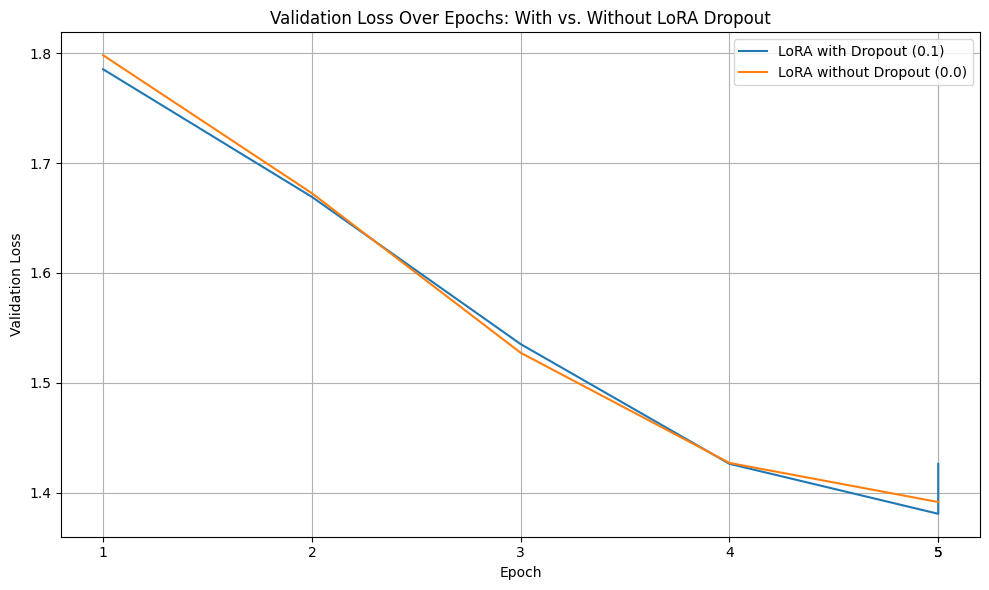

In [32]:
fig = plt.figure(figsize=(10, 6))
plt.plot(original_epochs, original_eval_losses, label='LoRA with Dropout (0.1)')
plt.plot(no_dropout_epochs, no_dropout_eval_losses, label='LoRA without Dropout (0.0)')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Validation Loss Over Epochs: With vs. Without LoRA Dropout')
plt.legend()
plt.grid(True)
plt.xticks(original_epochs) # Ensure integer ticks for epochs
plt.tight_layout()
plt.show()


From the plot above, we can observe the trend of validation loss for both models. A lower validation loss generally indicates better generalization. If the validation loss for the model *with* dropout is consistently lower or shows less increase towards the end of training compared to the model *without* dropout, it suggests that dropout is helping to mitigate overfitting.

### Further Experimentation: Alternate Dropout Rates and Multiple Seeds

To conduct a more thorough analysis, we will now experiment with different LoRA dropout rates and run each configuration with multiple random seeds. This will help us understand the variability and statistical significance of the results.

In [33]:
import random
import numpy as np
from transformers import set_seed # Hugging Face utility to set random seeds

# Define the dropout rates to experiment with
dropout_rates = [0.0, 0.05, 0.1, 0.2]
# Define the number of seeds per dropout rate
num_seeds = 3 # You can increase this to 5 or more for more robust statistical confirmation

# Generate a list of random seeds
seeds = [random.randint(0, 100000) for _ in range(num_seeds)]

# List to store all experimental results
# Each entry will be a dictionary containing dropout_rate, seed, final_eval_loss, final_eval_accuracy, and eval_loss_history
all_experiment_results = []

print(f"Experimenting with dropout rates: {dropout_rates}")
print(f"Using {num_seeds} seeds per rate: {seeds}")

Experimenting with dropout rates: [0.0, 0.05, 0.1, 0.2]
Using 3 seeds per rate: [83810, 14592, 3278]


### Data Loading and Preprocessing for Experiments

This section sets up all necessary data loading, preprocessing functions, and dataset splits needed for the multiple experiments. We are moving these definitions here to ensure they are consistently available and correctly initialized before each experimental run.

In [34]:
import evaluate
from datasets import load_dataset
from transformers import AutoImageProcessor
from torchvision.transforms import (
    CenterCrop,
    Compose,
    Normalize,
    RandomHorizontalFlip,
    RandomResizedCrop,
    Resize,
    ToTensor,
)

# --- Function Definitions (copied from Zxgrg45Xty2S, guYecwzyjLmj, qIicZRMrjNC3) ---
def print_trainable_parameters(model):
    """
    Prints the number of trainable parameters in the model.
    """
    trainable_params = 0
    all_param = 0
    for _, param in model.named_parameters():
        all_param += param.numel()
        if param.requires_grad:
            trainable_params += param.numel()
    print(
        f"trainable params: {trainable_params} || all params: {all_param} || trainable%: {100 * trainable_params / all_param:.2f}"
    )

metric = evaluate.load("accuracy")
def compute_metrics(eval_pred):
    """Computes accuracy on a batch of predictions"""
    predictions = np.argmax(eval_pred.predictions, axis=1)
    return metric.compute(predictions=predictions, references=eval_pred.label_ids)

def collate_fn(examples):
    pixel_values = torch.stack([example["pixel_values"] for example in examples])
    labels = torch.tensor([example["label"] for example in examples])
    return {"pixel_values": pixel_values, "labels": labels}

# --- Variable Definitions (copied from vhvCQpP-isJr, L8n6jj_7-aOw, GC3wK2aciz53, 3hmq4a_fi2IX, Zj33iIoCi3Uy, _uplVC66i5Gd, 0QuiqyiXi9fN) ---

model_checkpoint = "google/vit-base-patch16-224-in21k"
model_name = model_checkpoint.split("/")[-1]
batch_size = 128

# Load dataset
dataset = load_dataset("ethz/food101", split="train[:5000]")

# Prepare labels
labels = dataset.features["label"].names
label2id, id2label = dict(), dict()
for i, label in enumerate(labels):
    label2id[label] = i
    id2label[i] = label

# Prepare image processor
image_processor = AutoImageProcessor.from_pretrained(model_checkpoint)

# Define image transformations
normalize = Normalize(mean=image_processor.image_mean, std=image_processor.image_std)
train_transforms = Compose(
    [
        RandomResizedCrop(image_processor.size["height"]),
        RandomHorizontalFlip(),
        ToTensor(),
        normalize,
    ]
)
val_transforms = Compose(
    [
        Resize(image_processor.size["height"]),
        CenterCrop(image_processor.size["height"]),
        ToTensor(),
        normalize,
    ]
)
def preprocess_train(example_batch):
    """Apply train_transforms across a batch."""
    example_batch["pixel_values"] = [train_transforms(image.convert("RGB")) for image in example_batch["image"]]
    return example_batch
def preprocess_val(example_batch):
    """Apply val_transforms across a batch."""
    example_batch["pixel_values"] = [val_transforms(image.convert("RGB")) for image in example_batch["image"]]
    return example_batch

# Split and set transforms to dataset
splits = dataset.train_test_split(test_size=0.1)
train_ds = splits["train"]
val_ds = splits["test"]
train_ds.set_transform(preprocess_train)
val_ds.set_transform(preprocess_val)

print("Dataset, image processor, and data loaders prepared for experimentation.")

Dataset, image processor, and data loaders prepared for experimentation.


### Running Multiple Experiments

In [35]:
import gc
import torch
import random
import numpy as np
import evaluate
from datasets import load_dataset
from transformers import AutoModelForImageClassification, TrainingArguments, Trainer, set_seed, AutoImageProcessor
from peft import LoraConfig, get_peft_model
from torchvision.transforms import (
    CenterCrop,
    Compose,
    Normalize,
    RandomHorizontalFlip,
    RandomResizedCrop,
    Resize,
    ToTensor,
)

# --- Function Definitions (from other cells) ---
def print_trainable_parameters(model):
    """
    Prints the number of trainable parameters in the model.
    """
    trainable_params = 0
    all_param = 0
    for _, param in model.named_parameters():
        all_param += param.numel()
        if param.requires_grad:
            trainable_params += param.numel()
    print(
        f"trainable params: {trainable_params} || all params: {all_param} || trainable%: {100 * trainable_params / all_param:.2f}"
    )

metric = evaluate.load("accuracy")
def compute_metrics(eval_pred):
    """Computes accuracy on a batch of predictions"""
    predictions = np.argmax(eval_pred.predictions, axis=1)
    return metric.compute(predictions=predictions, references=eval_pred.label_ids)

def collate_fn(examples):
    pixel_values = torch.stack([example["pixel_values"] for example in examples])
    labels = torch.tensor([example["label"] for example in examples])
    return {"pixel_values": pixel_values, "labels": labels}

# --- Variable Definitions (from other cells) ---
model_checkpoint = "google/vit-base-patch16-224-in21k"
model_name = model_checkpoint.split("/")[-1]
batch_size = 128

# Load dataset
dataset = load_dataset("ethz/food101", split="train[:5000]")

# Prepare labels
labels = dataset.features["label"].names
label2id, id2label = dict(), dict()
for i, label in enumerate(labels):
    label2id[label] = i
    id2label[i] = label

# Prepare image processor
image_processor = AutoImageProcessor.from_pretrained(model_checkpoint)

# Define image transformations
normalize = Normalize(mean=image_processor.image_mean, std=image_processor.image_std)
train_transforms = Compose(
    [
        RandomResizedCrop(image_processor.size["height"]),
        RandomHorizontalFlip(),
        ToTensor(),
        normalize,
    ]
)
val_transforms = Compose(
    [
        Resize(image_processor.size["height"]),
        CenterCrop(image_processor.size["height"]),
        ToTensor(),
        normalize,
    ]
)
def preprocess_train(example_batch):
    """Apply train_transforms across a batch."""
    example_batch["pixel_values"] = [train_transforms(image.convert("RGB")) for image in example_batch["image"]]
    return example_batch
def preprocess_val(example_batch):
    """Apply val_transforms across a batch."""
    example_batch["pixel_values"] = [val_transforms(image.convert("RGB")) for image in example_batch["image"]]
    return example_batch

# Split and set transforms to dataset
splits = dataset.train_test_split(test_size=0.1)
train_ds = splits["train"]
val_ds = splits["test"]
train_ds.set_transform(preprocess_train)
val_ds.set_transform(preprocess_val)

# --- Experiment Loop ---
for dropout_rate in dropout_rates:
    for seed in seeds:
        print(f"\n--- Starting experiment: Dropout Rate = {dropout_rate}, Seed = {seed} ---")

        # 1. Set seed for reproducibility
        set_seed(seed)

        # 2. Re-initialize base model
        model_base = AutoModelForImageClassification.from_pretrained(
            model_checkpoint,
            label2id=label2id,
            id2label=id2label,
            ignore_mismatched_sizes=True,
        )

        # 3. Re-initialize LoRA config with current dropout rate
        config_current = LoraConfig(
            r=16,
            lora_alpha=16,
            target_modules=["q_proj", "v_proj"],
            lora_dropout=dropout_rate,
            bias="none",
            modules_to_save=["classifier"],
        )

        # 4. Get PEFT model
        lora_model_current = get_peft_model(model_base, config_current)
        print_trainable_parameters(lora_model_current)

        # 5. Re-initialize TrainingArguments
        model_name_current = f"{model_name}-lora-food101-dropout-{dropout_rate}-seed-{seed}"
        args_current = TrainingArguments(
            model_name_current,
            remove_unused_columns=False,
            eval_strategy="epoch",
            save_strategy="epoch",
            learning_rate=5e-3,
            per_device_train_batch_size=batch_size,
            gradient_accumulation_steps=4,
            per_device_eval_batch_size=batch_size,
            fp16=True,
            num_train_epochs=5,
            logging_steps=10,
            load_best_model_at_end=True,
            metric_for_best_model="accuracy",
            push_to_hub=False, # Set to False to avoid pushing numerous models
            label_names=["labels"],
        )

        # 6. Re-initialize Trainer
        trainer_current = Trainer(
            lora_model_current,
            args_current,
            train_dataset=train_ds,
            eval_dataset=val_ds,
            processing_class=image_processor,
            compute_metrics=compute_metrics,
            data_collator=collate_fn,
        )

        # 7. Train the model
        print(f"Training model with dropout {dropout_rate} and seed {seed}...")
        train_results_current = trainer_current.train()

        # 8. Evaluate the model
        eval_results_current = trainer_current.evaluate(val_ds)

        # 9. Store results
        experiment_data = {
            'dropout_rate': dropout_rate,
            'seed': seed,
            'final_eval_loss': eval_results_current['eval_loss'],
            'final_eval_accuracy': eval_results_current['eval_accuracy'],
            'log_history': trainer_current.state.log_history
        }
        all_experiment_results.append(experiment_data)

        print(f"Finished experiment: Dropout Rate = {dropout_rate}, Seed = {seed}")
        print(f"Final Eval Loss: {eval_results_current['eval_loss']:.4f}, Final Eval Accuracy: {eval_results_current['eval_accuracy']:.4f}")

        # Clean up memory
        del model_base, lora_model_current, trainer_current, args_current, train_results_current, eval_results_current
        torch.cuda.empty_cache()
        gc.collect()

print("\n--- All experiments completed! ---")
print(f"Total experiments run: {len(all_experiment_results)}")


--- Starting experiment: Dropout Rate = 0.0, Seed = 83810 ---


Loading weights:   0%|          | 0/6 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                                                     | Status     | 
--------------------------------------------------------+------------+-
encoder.layer.{0...11}.attention.output.dense.weight    | UNEXPECTED | 
encoder.layer.{0...11}.layernorm_after.weight           | UNEXPECTED | 
encoder.layer.{0...11}.intermediate.dense.weight        | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.value.bias   | UNEXPECTED | 
encoder.layer.{0...11}.layernorm_before.bias            | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.query.bias   | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.key.bias     | UNEXPECTED | 
encoder.layer.{0...11}.output.dense.weight              | UNEXPECTED | 
encoder.layer.{0...11}.intermediate.dense.bias          | UNEXPECTED | 
encoder.layer.{0...11}.attention.output.dense.bias      | UNEXPECTED | 
encoder.layer.{0...11}.layernorm_after.bias

trainable params: 667493 || all params: 86543818 || trainable%: 0.77
Training model with dropout 0.0 and seed 83810...


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,1.796329,0.308000
2,2.427400,1.628082,0.414000
3,1.692497,1.490474,0.454000
4,1.553243,1.369689,0.512000
5,1.417872,1.295360,0.536000


...

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                                                     | Status     | 
--------------------------------------------------------+------------+-
encoder.layer.{0...11}.attention.output.dense.weight    | UNEXPECTED | 
encoder.layer.{0...11}.layernorm_after.weight           | UNEXPECTED | 
encoder.layer.{0...11}.intermediate.dense.weight        | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.value.bias   | UNEXPECTED | 
encoder.layer.{0...11}.layernorm_before.bias            | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.query.bias   | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.key.bias     | UNEXPECTED | 
encoder.layer.{0...11}.output.dense.weight              | UNEXPECTED | 
encoder.layer.{0...11}.intermediate.dense.bias          | UNEXPECTED | 
encoder.layer.{0...11}.attention.output.dense.bias      | UNEXPECTED | 
encoder.layer.{0...11}.layernorm_after.bias

trainable params: 667493 || all params: 86543818 || trainable%: 0.77
Training model with dropout 0.2 and seed 3278...


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,1.798230,0.306000
2,2.453754,1.679608,0.344000
3,1.725604,1.560417,0.406000
4,1.593175,1.460764,0.434000
5,1.491030,1.377818,0.504000


Training Loss,Validation Loss,Epoch,Accuracy
1.491030,1.377818,5,0.504000


Finished experiment: Dropout Rate = 0.2, Seed = 3278
Final Eval Loss: 1.3778, Final Eval Accuracy: 0.5040

--- All experiments completed! ---
Total experiments run: 12


In [42]:
## New Experiment Setup

## Refined Experiment with Early Stopping

In [43]:
import random
import numpy as np
from transformers import set_seed # Hugging Face utility to set random seeds

# Define the dropout rates to experiment with for this refined experiment
refined_dropout_rates = [0.0, 0.5] # 0.5 is a common choice for regularization
# Define the number of seeds per dropout rate
num_seeds_refined = 3 # Can increase for more robust statistical confirmation

# Generate a list of random seeds
seeds_refined = [random.randint(0, 100000) for _ in range(num_seeds_refined)]

# List to store all refined experimental results
# Each entry will be a dictionary containing dropout_rate, seed, final_eval_loss, final_eval_accuracy, and eval_loss_history
all_refined_experiment_results = []

print(f"Experimenting with refined dropout rates: {refined_dropout_rates}")
print(f"Using {num_seeds_refined} seeds per rate: {seeds_refined}")

Experimenting with refined dropout rates: [0.0, 0.5]
Using 3 seeds per rate: [83810, 14592, 3278]


### Running Refined Experiments with Early Stopping

In [ ]:
import gc
import torch
from transformers import AutoModelForImageClassification, TrainingArguments, Trainer, EarlyStoppingCallback
from peft import LoraConfig, get_peft_model

# Ensure all necessary functions and variables from previous setup are available (e.g., from cell 2a5c8f9b)
# model_checkpoint, batch_size, label2id, id2label, image_processor, train_ds, val_ds, compute_metrics, collate_fn, print_trainable_parameters
# Assuming these are already defined in the environment from previous executed cells like 2a5c8f9b

# Experiment Loop with Early Stopping
for dropout_rate in refined_dropout_rates:
    for seed in seeds_refined:
        print(f"\n--- Starting REFINED experiment: Dropout Rate = {dropout_rate}, Seed = {seed} ---")

        # 1. Set seed for reproducibility
        set_seed(seed)

        # 2. Re-initialize base model
        model_base_refined = AutoModelForImageClassification.from_pretrained(
            model_checkpoint,
            label2id=label2id,
            id2label=id2label,
            ignore_mismatched_sizes=True,
        )

        # 3. Re-initialize LoRA config with current dropout rate
        config_current_refined = LoraConfig(
            r=16,
            lora_alpha=16,
            target_modules=["q_proj", "v_proj"],
            lora_dropout=dropout_rate,
            bias="none",
            modules_to_save=["classifier"],
        )

        # 4. Get PEFT model
        lora_model_current_refined = get_peft_model(model_base_refined, config_current_refined)
        print_trainable_parameters(lora_model_current_refined)

        # 5. Re-initialize TrainingArguments with EarlyStoppingCallback
        model_name_current_refined = f"{model_name}-lora-food101-refined-dropout-{dropout_rate}-seed-{seed}"
        args_current_refined = TrainingArguments(
            model_name_current_refined,
            remove_unused_columns=False,
            eval_strategy="epoch",
            save_strategy="epoch",
            learning_rate=5e-3,
            per_device_train_batch_size=batch_size,
            gradient_accumulation_steps=4,
            per_device_eval_batch_size=batch_size,
            fp16=True,
            num_train_epochs=50, # Set a higher number of epochs to allow early stopping to take effect
            logging_steps=10,
            load_best_model_at_end=True,
            metric_for_best_model="eval_loss", # Monitor validation loss for early stopping
            greater_is_better=False, # Lower loss is better
            push_to_hub=False, # Set to False to avoid pushing numerous models
            label_names=["labels"],
        )

        # 6. Initialize Trainer with EarlyStoppingCallback
        trainer_current_refined = Trainer(
            lora_model_current_refined,
            args_current_refined,
            train_dataset=train_ds,
            eval_dataset=val_ds,
            processing_class=image_processor,
            compute_metrics=compute_metrics,
            data_collator=collate_fn,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=5, early_stopping_threshold=0.001)] # Stop if eval_loss doesn't improve by at least 0.001 for 5 epochs
        )

        # 7. Train the model
        print(f"Training model with dropout {dropout_rate} and seed {seed} (with early stopping)...")
        train_results_current_refined = trainer_current_refined.train()

        # 8. Evaluate the model (will load the best model due to load_best_model_at_end=True)
        eval_results_current_refined = trainer_current_refined.evaluate(val_ds)

        # 9. Store results
        experiment_data_refined = {
            'dropout_rate': dropout_rate,
            'seed': seed,
            'final_eval_loss': eval_results_current_refined['eval_loss'],
            'final_eval_accuracy': eval_results_current_refined['eval_accuracy'],
            'log_history': trainer_current_refined.state.log_history
        }
        all_refined_experiment_results.append(experiment_data_refined)

        print(f"Finished REFINED experiment: Dropout Rate = {dropout_rate}, Seed = {seed}")
        print(f"Final Eval Loss: {eval_results_current_refined['eval_loss']:.4f}, Final Eval Accuracy: {eval_results_current_refined['eval_accuracy']:.4f}")

        # Clean up memory
        del model_base_refined, lora_model_current_refined, trainer_current_refined, args_current_refined, train_results_current_refined, eval_results_current_refined
        torch.cuda.empty_cache()
        gc.collect()

print("\n--- All refined experiments completed! ---")
print(f"Total refined experiments run: {len(all_refined_experiment_results)}")


--- Starting REFINED experiment: Dropout Rate = 0.0, Seed = 83810 ---


Loading weights:   0%|          | 0/6 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                                                     | Status     | 
--------------------------------------------------------+------------+-
encoder.layer.{0...11}.attention.output.dense.weight    | UNEXPECTED | 
encoder.layer.{0...11}.layernorm_after.weight           | UNEXPECTED | 
encoder.layer.{0...11}.intermediate.dense.weight        | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.value.bias   | UNEXPECTED | 
encoder.layer.{0...11}.layernorm_before.bias            | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.query.bias   | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.key.bias     | UNEXPECTED | 
encoder.layer.{0...11}.output.dense.weight              | UNEXPECTED | 
encoder.layer.{0...11}.intermediate.dense.bias          | UNEXPECTED | 
encoder.layer.{0...11}.attention.output.dense.bias      | UNEXPECTED | 
encoder.layer.{0...11}.layernorm_after.bias

trainable params: 667493 || all params: 86543818 || trainable%: 0.77
Training model with dropout 0.0 and seed 83810 (with early stopping)...


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,1.772859,0.318000
2,2.418758,1.603870,0.428000
3,1.697716,1.406822,0.478000
4,1.524825,1.448007,0.482000
5,1.465594,1.284101,0.516000
6,1.312540,1.140694,0.604000
7,1.244997,1.155269,0.582000
8,1.197700,1.056273,0.636000
9,1.160083,1.071400,0.628000
10,1.130289,1.037771,0.654000


...

Finished REFINED experiment: Dropout Rate = 0.0, Seed = 83810
Final Eval Loss: 0.7909, Final Eval Accuracy: 0.7060

--- Starting REFINED experiment: Dropout Rate = 0.0, Seed = 14592 ---


Loading weights:   0%|          | 0/6 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                                                     | Status     | 
--------------------------------------------------------+------------+-
encoder.layer.{0...11}.attention.output.dense.weight    | UNEXPECTED | 
encoder.layer.{0...11}.layernorm_after.weight           | UNEXPECTED | 
encoder.layer.{0...11}.intermediate.dense.weight        | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.value.bias   | UNEXPECTED | 
encoder.layer.{0...11}.layernorm_before.bias            | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.query.bias   | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.key.bias     | UNEXPECTED | 
encoder.layer.{0...11}.output.dense.weight              | UNEXPECTED | 
encoder.layer.{0...11}.intermediate.dense.bias          | UNEXPECTED | 
encoder.layer.{0...11}.attention.output.dense.bias      | UNEXPECTED | 
encoder.layer.{0...11}.layernorm_after.bias

trainable params: 667493 || all params: 86543818 || trainable%: 0.77
Training model with dropout 0.0 and seed 14592 (with early stopping)...


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,1.782784,0.286000
2,2.416145,1.660425,0.366000
3,1.723011,1.474612,0.438000


### Plotting Validation Loss with Early Stopping

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

# Group results by dropout rate
results_by_dropout = {}
for result in all_refined_experiment_results:
    dr = result['dropout_rate']
    if dr not in results_by_dropout:
        results_by_dropout[dr] = []
    results_by_dropout[dr].append(result)

for dropout_rate, runs in results_by_dropout.items():
    for i, run in enumerate(runs):
        log_history = run['log_history']
        eval_logs = [log for log in log_history if 'eval_loss' in log and 'epoch' in log]
        epochs = [log['epoch'] for log in eval_logs]
        eval_losses = [log['eval_loss'] for log in eval_logs]

        if epochs and eval_losses:
            # Ensure epochs are unique for plotting
            df = pd.DataFrame({'epoch': epochs, 'eval_loss': eval_losses}).drop_duplicates(subset=['epoch']).sort_values('epoch')
            plt.plot(df['epoch'], df['eval_loss'], label=f'Dropout {dropout_rate}, Seed {run['seed']}', alpha=0.8)

plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Validation Loss Over Epochs with Early Stopping (Refined Experiment)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

print("\n--- Summary of Refined Experiments ---")
for result in all_refined_experiment_results:
    print(f"Dropout: {result['dropout_rate']}, Seed: {result['seed']}, Final Eval Loss: {result['final_eval_loss']:.4f}, Final Eval Accuracy: {result['final_eval_accuracy']:.4f}")

Don't worry about the warnings, they're harmless.

Let's now fetch a sample for inference.

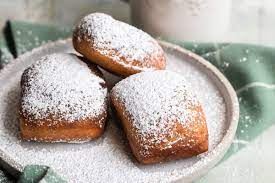

In [36]:
from PIL import Image
import requests

url = "https://huggingface.co/datasets/sayakpaul/sample-datasets/resolve/main/beignets.jpeg"
image = Image.open(requests.get(url, stream=True).raw)
image

We first instantiate an `image_processor` from the underlying model repo.

In [37]:
image_processor = AutoImageProcessor.from_pretrained(repo_name)

preprocessor_config.json:   0%|          | 0.00/325 [00:00<?, ?B/s]

We then prepare the sample for inference.

In [38]:
# prepare image for the model
encoding = image_processor(image.convert("RGB"), return_tensors="pt")
print(encoding.pixel_values.shape)

torch.Size([1, 3, 224, 224])


And run inference!

In [39]:
import torch

# forward pass
with torch.no_grad():
    outputs = inference_model(**encoding)
    logits = outputs.logits

predicted_class_idx = logits.argmax(-1).item()
print("Predicted class:", inference_model.config.id2label[predicted_class_idx])

Predicted class: grilled_cheese_sandwich
